<a href="https://colab.research.google.com/github/Vyshnavi262007/Student_prediction_using_ANN/blob/main/student_prediction_microproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

In [ ]:
# 2. Load dataset
# Upload the Excel file in Colab first, then use its name here
df = pd.read_excel("Dataset Project 404.xlsx", sheet_name="original")


In [ ]:
# 3. Select required columns
# Input features (student academic/skill-related features)
features = [
    'Linguistic',
    'Musical',
    'Bodily',
    'Logical - Mathematical',
    'Spatial-Visualization',
    'Interpersonal',
    'Intrapersonal',
    'Naturalist'
]
# Target column (career/job recommendation)
target = 'Job profession'

In [ ]:
# 4. Clean dataset
df = df[features + [target]].copy()
df[target] = df[target].astype(str).str.strip()
df = df.dropna()


In [ ]:
# 5. Prepare X and y
X = df[features].values
y = df[target].values

In [ ]:
# 6. Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Convert target into one-hot encoding
y_categorical = to_categorical(y_encoded)


In [ ]:
# 7. Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)


In [ ]:
# 8. Perform data preprocessing (feature scaling)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 9. Define ANN architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(y_categorical.shape[1], activation='softmax')   # output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 10. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 11. Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1302 - loss: 3.7979 - val_accuracy: 0.4010 - val_loss: 2.8461
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4470 - loss: 2.1580 - val_accuracy: 0.7535 - val_loss: 1.2512
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6150 - loss: 1.2844 - val_accuracy: 0.8212 - val_loss: 0.7580
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6849 - loss: 0.9798 - val_accuracy: 0.8472 - val_loss: 0.5514
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7161 - loss: 0.8294 - val_accuracy: 0.8628 - val_loss: 0.4788
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7444 - loss: 0.7305 - val_accuracy: 0.8785 - val_loss: 0.4170
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7726 - loss: 0.6286 - val_accuracy: 0.8663 - val_loss: 0.3861
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7760 - loss: 0.5907 - val_accuracy: 0.

In [ ]:
# 12. Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.1939806342124939
Test Accuracy: 0.925000011920929


In [ ]:
# 13. Predict on test data
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
# 14. Calculate classification metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\nClassification Metrics:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)


Classification Metrics:
Accuracy : 0.925
Precision: 0.9316656144781145
Recall   : 0.925
F1-Score : 0.9223747551134033


In [ ]:
# 15. Print classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))



Classification Report:

                                                                                                precision    recall  f1-score   support

                                                                               Actor / Actress       0.91      1.00      0.95        10
                                                                                       Actuary       0.91      1.00      0.95        10
                                                                                Anthropologist       1.00      1.00      1.00        10
                                                                                  Archeologist       1.00      1.00      1.00        10
                                                                                        Artist       1.00      1.00      1.00        10
                                                                                    Astronomer       1.00      1.00      1.00        10
                      

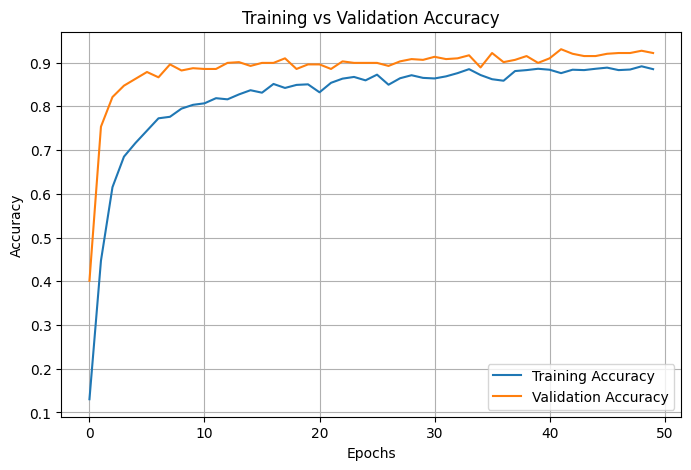

In [ ]:
# 16. Plot training and validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

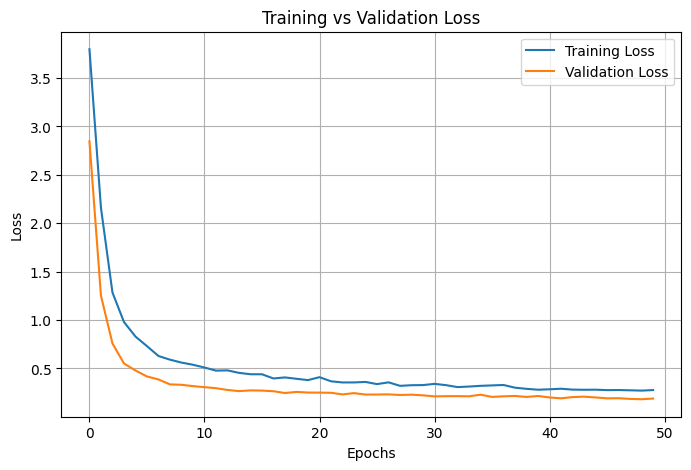

In [ ]:
# 17. Plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 18. Predict career for a new student
sample_student = np.array([[15, 8, 12, 18, 16, 14, 17, 10]])
# Example order:
# Linguistic, Musical, Bodily, Logical-Mathematical, Spatial-Visualization,
# Interpersonal, Intrapersonal, Naturalist

sample_student_scaled = scaler.transform(sample_student)
sample_pred = model.predict(sample_student_scaled)
predicted_class = np.argmax(sample_pred, axis=1)[0]
predicted_job = label_encoder.inverse_transform([predicted_class])[0]

print("\nRecommended Career Path for sample student:", predicted_job)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

Recommended Career Path for sample student: Engineer
